ML Project Workspace

Note for the TA: To run our code the dataset (cleaned and raw) is within our google drive and we gave you all access to the drive. You just need to create a shortcut to match the path we are using to call the file.

Uncleaned Initial Summary Stats

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
from pathlib import Path
CSV_PATH = Path("/content/drive/MyDrive/CSCI3052U - Group Project (Team 9)/34100154-eng (Unzipped Files)/Raw_Data.csv")


df = pd.read_csv(CSV_PATH)

/tmp/ipykernel_2569/1569815213.py:6: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(CSV_PATH)


In [ ]:
df.head()

,REF_DATE,GEO,DGUID,Housing estimates,Type of unit,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,1972-01,Census metropolitan areas,NaN,Housing starts,Total units,Units,300,units,0,v42127250,1.1.1,7969,NaN,NaN,NaN,0
1,1972-01,Census metropolitan areas,NaN,Housing starts,Single-detached units,Units,300,units,0,v42127251,1.1.2,3287,NaN,NaN,NaN,0
2,1972-01,Census metropolitan areas,NaN,Housing starts,Semi-detached units,Units,300,units,0,v42127252,1.1.3,615,NaN,NaN,NaN,0
3,1972-01,Census metropolitan areas,NaN,Housing starts,Row units,Units,300,units,0,v42127253,1.1.4,734,NaN,NaN,NaN,0
4,1972-01,Census metropolitan areas,NaN,Housing starts,Apartment and other unit types,Units,300,units,0,v42127254,1.1.5,3333,NaN,NaN,NaN,0


In [ ]:
df.shape

(343440, 16)

In [ ]:
df.columns.tolist()

['REF_DATE',
 'GEO',
 'DGUID',
 'Housing estimates',
 'Type of unit',
 'UOM',
 'UOM_ID',
 'SCALAR_FACTOR',
 'SCALAR_ID',
 'VECTOR',
 'COORDINATE',
 'VALUE',
 'STATUS',
 'SYMBOL',
 'TERMINATED',
 'DECIMALS']

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 343440 entries, 0 to 343439
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   REF_DATE           343440 non-null  object 
 1   GEO                343440 non-null  object 
 2   DGUID              328920 non-null  object 
 3   Housing estimates  343440 non-null  object 
 4   Type of unit       343440 non-null  object 
 5   UOM                343440 non-null  object 
 6   UOM_ID             343440 non-null  int64  
 7   SCALAR_FACTOR      343440 non-null  object 
 8   SCALAR_ID          343440 non-null  int64  
 9   VECTOR             343440 non-null  object 
 10  COORDINATE         343440 non-null  object 
 11  VALUE              343440 non-null  int64  
 12  STATUS             0 non-null       float64
 13  SYMBOL             0 non-null       float64
 14  TERMINATED         4680 non-null    object 
 15  DECIMALS           343440 non-null  int64  
dtypes:

In [ ]:
df["REF_DATE"].min(), df["REF_DATE"].max()

('1972-01', '2026-08')

In [ ]:
df["Housing estimates"].value_counts()

,count
Housing estimates,
Housing starts,114480
Housing under construction,114480
Housing completions,114480


In [ ]:
df["Type of unit"].value_counts()

,count
Type of unit,
Total units,68688
Single-detached units,68688
Semi-detached units,68688
Row units,68688
Apartment and other unit types,68688


In [ ]:
df["GEO"].unique()

array(['Census metropolitan areas', 'Brantford, Ontario',
       'Calgary, Alberta', 'Edmonton, Alberta',
       'Greater Sudbury, Ontario', 'Guelph, Ontario',
       'Halifax, Nova Scotia', 'Hamilton, Ontario', 'Kingston, Ontario',
       'Kitchener-Cambridge-Waterloo, Ontario', 'London, Ontario',
       'Moncton, New Brunswick',
       'Montréal excluding Saint-Jérôme, Quebec',
       'Ottawa-Gatineau, Ontario/Quebec',
       'Ottawa-Gatineau, Ontario part, Ontario/Quebec',
       'Ottawa-Gatineau, Quebec part, Ontario/Quebec',
       'Peterborough, Ontario', 'Québec, Quebec', 'Regina, Saskatchewan',
       'St. Catharines-Niagara, Ontario',
       "St. John's, Newfoundland and Labrador",
       'Saint John, New Brunswick', 'Saguenay, Quebec',
       'Saskatoon, Saskatchewan', 'Thunder Bay, Ontario',
       'Toronto, Ontario', 'Vancouver, British Columbia',
       'Victoria, British Columbia', 'Windsor, Ontario',
       'Winnipeg, Manitoba', 'Kelowna, British Columbia',
       'Oshaw

In [ ]:
df["GEO"].nunique()

37

In [ ]:
df["GEO"].value_counts().head(50)

,count
GEO,
Census metropolitan areas,9840
"Brantford, Ontario",9840
"Calgary, Alberta",9840
"Edmonton, Alberta",9840
"Greater Sudbury, Ontario",9840
"Guelph, Ontario",9840
"Halifax, Nova Scotia",9840
"Hamilton, Ontario",9840
"Kingston, Ontario",9840


In [ ]:
project_view = df[
    (df["Housing estimates"] == "Housing starts") &
    (df["Type of unit"] == "Total units")
][["REF_DATE", "GEO", "VALUE"]].copy()

project_view.head()

,REF_DATE,GEO,VALUE
0,1972-01,Census metropolitan areas,7969
15,1972-01,"Brantford, Ontario",9
30,1972-01,"Calgary, Alberta",322
45,1972-01,"Edmonton, Alberta",275
60,1972-01,"Greater Sudbury, Ontario",21


In [ ]:
project_view.shape

(22896, 3)

In [ ]:
project_view.groupby("GEO")["REF_DATE"].agg(["min", "max", "count"])

,min,max,count
GEO,,,
"Abbotsford-Mission, British Columbia",1987-01,2026-08,476
"Barrie, Ontario",1982-01,2026-08,536
"Brantford, Ontario",1972-01,2026-08,656
"Calgary, Alberta",1972-01,2026-08,656
Census metropolitan areas,1972-01,2026-08,656
"Edmonton, Alberta",1972-01,2026-08,656
"Greater Sudbury, Ontario",1972-01,2026-08,656
"Guelph, Ontario",1972-01,2026-08,656
"Halifax, Nova Scotia",1972-01,2026-08,656


Data Cleaning

In [ ]:
df["GEO"].unique()

array(['Census metropolitan areas', 'Brantford, Ontario',
       'Calgary, Alberta', 'Edmonton, Alberta',
       'Greater Sudbury, Ontario', 'Guelph, Ontario',
       'Halifax, Nova Scotia', 'Hamilton, Ontario', 'Kingston, Ontario',
       'Kitchener-Cambridge-Waterloo, Ontario', 'London, Ontario',
       'Moncton, New Brunswick',
       'Montréal excluding Saint-Jérôme, Quebec',
       'Ottawa-Gatineau, Ontario/Quebec',
       'Ottawa-Gatineau, Ontario part, Ontario/Quebec',
       'Ottawa-Gatineau, Quebec part, Ontario/Quebec',
       'Peterborough, Ontario', 'Québec, Quebec', 'Regina, Saskatchewan',
       'St. Catharines-Niagara, Ontario',
       "St. John's, Newfoundland and Labrador",
       'Saint John, New Brunswick', 'Saguenay, Quebec',
       'Saskatoon, Saskatchewan', 'Thunder Bay, Ontario',
       'Toronto, Ontario', 'Vancouver, British Columbia',
       'Victoria, British Columbia', 'Windsor, Ontario',
       'Winnipeg, Manitoba', 'Kelowna, British Columbia',
       'Oshaw

In [ ]:
df = df[(df["GEO"] != "Census metropolitan areas") &
        (df["GEO"] != "Ottawa-Gatineau, Ontario part, Ontario/Quebec") &
        (df["GEO"] != "Ottawa-Gatineau, Quebec part, Ontario/Quebec") &
        (df["GEO"] != "Montréal excluding Saint-Jérôme, Quebec")]

In [ ]:
df

,REF_DATE,GEO,DGUID,Housing estimates,Type of unit,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
15,1972-01,"Brantford, Ontario",2011S0503543,Housing starts,Total units,Units,300,units,0,v42135827,33.1.1,9,NaN,NaN,NaN,0
16,1972-01,"Brantford, Ontario",2011S0503543,Housing starts,Single-detached units,Units,300,units,0,v42135823,33.1.2,9,NaN,NaN,NaN,0
17,1972-01,"Brantford, Ontario",2011S0503543,Housing starts,Semi-detached units,Units,300,units,0,v42135824,33.1.3,0,NaN,NaN,NaN,0
18,1972-01,"Brantford, Ontario",2011S0503543,Housing starts,Row units,Units,300,units,0,v42135825,33.1.4,0,NaN,NaN,NaN,0
19,1972-01,"Brantford, Ontario",2011S0503543,Housing starts,Apartment and other unit types,Units,300,units,0,v42135826,33.1.5,0,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
343435,2026-08,"Winnipeg, Manitoba",2011S0503602,Housing completions,Total units,Units,300,units,0,v42127560,28.3.1,412,NaN,NaN,NaN,0
343436,2026-08,"Winnipeg, Manitoba",2011S0503602,Housing completions,Single-detached units,Units,300,units,0,v42127561,28.3.2,149,NaN,NaN,NaN,0
343437,2026-08,"Winnipeg, Manitoba",2011S0503602,Housing completions,Semi-detached units,Units,300,units,0,v42127562,28.3.3,38,NaN,NaN,NaN,0
343438,2026-08,"Winnipeg, Manitoba",2011S0503602,Housing completions,Row units,Units,300,units,0,v42127563,28.3.4,121,NaN,NaN,NaN,0


In [ ]:
print(df["VALUE"].isna().sum())

0


In [ ]:
print(df.duplicated().sum())

0


In [ ]:
df["REF_DATE"] = pd.to_datetime(df["REF_DATE"])

In [ ]:
df

,REF_DATE,GEO,DGUID,Housing estimates,Type of unit,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
15,1972-01-01,"Brantford, Ontario",2011S0503543,Housing starts,Total units,Units,300,units,0,v42135827,33.1.1,9,NaN,NaN,NaN,0
16,1972-01-01,"Brantford, Ontario",2011S0503543,Housing starts,Single-detached units,Units,300,units,0,v42135823,33.1.2,9,NaN,NaN,NaN,0
17,1972-01-01,"Brantford, Ontario",2011S0503543,Housing starts,Semi-detached units,Units,300,units,0,v42135824,33.1.3,0,NaN,NaN,NaN,0
18,1972-01-01,"Brantford, Ontario",2011S0503543,Housing starts,Row units,Units,300,units,0,v42135825,33.1.4,0,NaN,NaN,NaN,0
19,1972-01-01,"Brantford, Ontario",2011S0503543,Housing starts,Apartment and other unit types,Units,300,units,0,v42135826,33.1.5,0,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
343435,2026-08-01,"Winnipeg, Manitoba",2011S0503602,Housing completions,Total units,Units,300,units,0,v42127560,28.3.1,412,NaN,NaN,NaN,0
343436,2026-08-01,"Winnipeg, Manitoba",2011S0503602,Housing completions,Single-detached units,Units,300,units,0,v42127561,28.3.2,149,NaN,NaN,NaN,0
343437,2026-08-01,"Winnipeg, Manitoba",2011S0503602,Housing completions,Semi-detached units,Units,300,units,0,v42127562,28.3.3,38,NaN,NaN,NaN,0
343438,2026-08-01,"Winnipeg, Manitoba",2011S0503602,Housing completions,Row units,Units,300,units,0,v42127563,28.3.4,121,NaN,NaN,NaN,0


In [ ]:
print((df["VALUE"] < 0).sum())

0


In [ ]:
print(df["STATUS"].value_counts(dropna=False))
print(df["SYMBOL"].value_counts(dropna=False))
print(df["TERMINATED"].value_counts(dropna=False))

STATUS
NaN    309240
Name: count, dtype: int64
SYMBOL
NaN    309240
Name: count, dtype: int64
TERMINATED
NaN    309240
Name: count, dtype: int64


In [ ]:
print(df["SCALAR_ID"].unique())

[0]


In [ ]:
df = df.drop(columns=["SCALAR_ID", "UOM_ID", "VECTOR", "COORDINATE", "STATUS", "SYMBOL", "TERMINATED", "DGUID", "DECIMALS", "UOM", "SCALAR_FACTOR"])

In [ ]:
df

,REF_DATE,GEO,Housing estimates,Type of unit,VALUE
15,1972-01-01,"Brantford, Ontario",Housing starts,Total units,9
16,1972-01-01,"Brantford, Ontario",Housing starts,Single-detached units,9
17,1972-01-01,"Brantford, Ontario",Housing starts,Semi-detached units,0
18,1972-01-01,"Brantford, Ontario",Housing starts,Row units,0
19,1972-01-01,"Brantford, Ontario",Housing starts,Apartment and other unit types,0
...,...,...,...,...,...
343435,2026-08-01,"Winnipeg, Manitoba",Housing completions,Total units,412
343436,2026-08-01,"Winnipeg, Manitoba",Housing completions,Single-detached units,149
343437,2026-08-01,"Winnipeg, Manitoba",Housing completions,Semi-detached units,38
343438,2026-08-01,"Winnipeg, Manitoba",Housing completions,Row units,121


In [ ]:
df = df.sort_values(["GEO", "Housing estimates", "Type of unit", "REF_DATE"]).reset_index(drop=True)

In [ ]:
df

,REF_DATE,GEO,Housing estimates,Type of unit,VALUE
0,1987-01-01,"Abbotsford-Mission, British Columbia",Housing completions,Apartment and other unit types,30
1,1987-02-01,"Abbotsford-Mission, British Columbia",Housing completions,Apartment and other unit types,0
2,1987-03-01,"Abbotsford-Mission, British Columbia",Housing completions,Apartment and other unit types,24
3,1987-04-01,"Abbotsford-Mission, British Columbia",Housing completions,Apartment and other unit types,0
4,1987-05-01,"Abbotsford-Mission, British Columbia",Housing completions,Apartment and other unit types,81
...,...,...,...,...,...
309235,2026-04-01,"Winnipeg, Manitoba",Housing under construction,Total units,8773
309236,2026-05-01,"Winnipeg, Manitoba",Housing under construction,Total units,9246
309237,2026-06-01,"Winnipeg, Manitoba",Housing under construction,Total units,8947
309238,2026-07-01,"Winnipeg, Manitoba",Housing under construction,Total units,9105


In [ ]:
df = df[df["Type of unit"]=="Total units"]

In [ ]:
df

,REF_DATE,GEO,Housing estimates,Type of unit,VALUE
1904,1987-01-01,"Abbotsford-Mission, British Columbia",Housing completions,Total units,74
1905,1987-02-01,"Abbotsford-Mission, British Columbia",Housing completions,Total units,43
1906,1987-03-01,"Abbotsford-Mission, British Columbia",Housing completions,Total units,75
1907,1987-04-01,"Abbotsford-Mission, British Columbia",Housing completions,Total units,56
1908,1987-05-01,"Abbotsford-Mission, British Columbia",Housing completions,Total units,180
...,...,...,...,...,...
309235,2026-04-01,"Winnipeg, Manitoba",Housing under construction,Total units,8773
309236,2026-05-01,"Winnipeg, Manitoba",Housing under construction,Total units,9246
309237,2026-06-01,"Winnipeg, Manitoba",Housing under construction,Total units,8947
309238,2026-07-01,"Winnipeg, Manitoba",Housing under construction,Total units,9105


In [ ]:
df = df[df["Housing estimates"]=="Housing starts"]

In [ ]:
df

,REF_DATE,GEO,Housing estimates,Type of unit,VALUE
4284,1987-01-01,"Abbotsford-Mission, British Columbia",Housing starts,Total units,26
4285,1987-02-01,"Abbotsford-Mission, British Columbia",Housing starts,Total units,70
4286,1987-03-01,"Abbotsford-Mission, British Columbia",Housing starts,Total units,145
4287,1987-04-01,"Abbotsford-Mission, British Columbia",Housing starts,Total units,224
4288,1987-05-01,"Abbotsford-Mission, British Columbia",Housing starts,Total units,214
...,...,...,...,...,...
305955,2026-04-01,"Winnipeg, Manitoba",Housing starts,Total units,766
305956,2026-05-01,"Winnipeg, Manitoba",Housing starts,Total units,668
305957,2026-06-01,"Winnipeg, Manitoba",Housing starts,Total units,851
305958,2026-07-01,"Winnipeg, Manitoba",Housing starts,Total units,545


In [ ]:
df.to_csv("/content/drive/MyDrive/CSCI3052U - Group Project (Team 9)/cleaned_housing.csv", index=False)

In [ ]:
pd.read_csv("/content/drive/MyDrive/CSCI3052U - Group Project (Team 9)/cleaned_housing.csv")

,REF_DATE,GEO,Housing estimates,Type of unit,VALUE
0,1987-01-01,"Abbotsford-Mission, British Columbia",Housing starts,Total units,26
1,1987-02-01,"Abbotsford-Mission, British Columbia",Housing starts,Total units,70
2,1987-03-01,"Abbotsford-Mission, British Columbia",Housing starts,Total units,145
3,1987-04-01,"Abbotsford-Mission, British Columbia",Housing starts,Total units,224
4,1987-05-01,"Abbotsford-Mission, British Columbia",Housing starts,Total units,214
...,...,...,...,...,...
20611,2026-04-01,"Winnipeg, Manitoba",Housing starts,Total units,766
20612,2026-05-01,"Winnipeg, Manitoba",Housing starts,Total units,668
20613,2026-06-01,"Winnipeg, Manitoba",Housing starts,Total units,851
20614,2026-07-01,"Winnipeg, Manitoba",Housing starts,Total units,545


EDA and Visualization

In [ ]:
import pandas as pd

clean_df = pd.read_csv("/content/drive/MyDrive/CSCI3052U - Group Project (Team 9)/cleaned_housing.csv")

clean_df.head()

,REF_DATE,GEO,Housing estimates,Type of unit,VALUE
0,1987-01-01,"Abbotsford-Mission, British Columbia",Housing starts,Total units,26
1,1987-02-01,"Abbotsford-Mission, British Columbia",Housing starts,Total units,70
2,1987-03-01,"Abbotsford-Mission, British Columbia",Housing starts,Total units,145
3,1987-04-01,"Abbotsford-Mission, British Columbia",Housing starts,Total units,224
4,1987-05-01,"Abbotsford-Mission, British Columbia",Housing starts,Total units,214


In [ ]:
clean_df.shape

(20616, 5)

In [ ]:
clean_df.columns.tolist()

['REF_DATE', 'GEO', 'Housing estimates', 'Type of unit', 'VALUE']

In [ ]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20616 entries, 0 to 20615
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   REF_DATE           20616 non-null  object
 1   GEO                20616 non-null  object
 2   Housing estimates  20616 non-null  object
 3   Type of unit       20616 non-null  object
 4   VALUE              20616 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 805.4+ KB


In [ ]:
clean_df["REF_DATE"].min(), clean_df["REF_DATE"].max()

('1972-01-01', '2026-08-01')

In [ ]:
clean_df["GEO"].nunique()

33

In [ ]:
clean_df["GEO"].unique()

array(['Abbotsford-Mission, British Columbia', 'Barrie, Ontario',
       'Brantford, Ontario', 'Calgary, Alberta', 'Edmonton, Alberta',
       'Greater Sudbury, Ontario', 'Guelph, Ontario',
       'Halifax, Nova Scotia', 'Hamilton, Ontario',
       'Kelowna, British Columbia', 'Kingston, Ontario',
       'Kitchener-Cambridge-Waterloo, Ontario', 'London, Ontario',
       'Moncton, New Brunswick', 'Montréal, Quebec', 'Oshawa, Ontario',
       'Ottawa-Gatineau, Ontario/Quebec', 'Peterborough, Ontario',
       'Québec, Quebec', 'Regina, Saskatchewan', 'Saguenay, Quebec',
       'Saint John, New Brunswick', 'Saskatoon, Saskatchewan',
       'Sherbrooke, Quebec', 'St. Catharines-Niagara, Ontario',
       "St. John's, Newfoundland and Labrador", 'Thunder Bay, Ontario',
       'Toronto, Ontario', 'Trois-Rivières, Quebec',
       'Vancouver, British Columbia', 'Victoria, British Columbia',
       'Windsor, Ontario', 'Winnipeg, Manitoba'], dtype=object)

In [ ]:
clean_df.describe()

,VALUE
count,20616.000000
mean,360.161088
std,636.899189
min,0.000000
25%,51.000000
50%,127.000000
75%,327.000000
max,7171.000000


In [ ]:
clean_df.groupby("GEO")["REF_DATE"].agg(["min", "max", "count"])

,min,max,count
GEO,,,
"Abbotsford-Mission, British Columbia",1987-01-01,2026-08-01,476
"Barrie, Ontario",1982-01-01,2026-08-01,536
"Brantford, Ontario",1972-01-01,2026-08-01,656
"Calgary, Alberta",1972-01-01,2026-08-01,656
"Edmonton, Alberta",1972-01-01,2026-08-01,656
"Greater Sudbury, Ontario",1972-01-01,2026-08-01,656
"Guelph, Ontario",1972-01-01,2026-08-01,656
"Halifax, Nova Scotia",1972-01-01,2026-08-01,656
"Hamilton, Ontario",1972-01-01,2026-08-01,656


In [ ]:
cma_summary = (
    clean_df.groupby("GEO")["VALUE"]
    .agg(["count", "mean", "median", "min", "max", "std"])
    .sort_values("mean", ascending=False)
)

cma_summary

,count,mean,median,min,max,std
GEO,,,,,,
"Toronto, Ontario",656,2675.585366,2593.5,351,7171,1143.825810
"Montréal, Quebec",344,1767.398256,1709.5,0,3713,708.879464
"Vancouver, British Columbia",656,1486.864329,1420.0,330,4167,623.552285
"Calgary, Alberta",656,904.919207,848.0,57,3102,520.992929
"Edmonton, Alberta",656,803.022866,725.0,90,2689,459.954357
"Ottawa-Gatineau, Ontario/Quebec",656,728.570122,679.0,43,2835,391.683625
"Québec, Quebec",656,449.100610,408.0,0,2045,271.259565
"Winnipeg, Manitoba",656,325.512195,261.0,2,1656,237.016725
"Hamilton, Ontario",656,287.993902,240.0,8,1390,199.187418


In [ ]:
monthly_total = (
    clean_df.groupby("REF_DATE")["VALUE"]
    .sum()
    .reset_index()
)

monthly_total.head()

,REF_DATE,VALUE
0,1972-01-01,6917
1,1972-02-01,8018
2,1972-03-01,10123
3,1972-04-01,11475
4,1972-05-01,15912


In [ ]:
monthly_total.tail()

,REF_DATE,VALUE
651,2026-04-01,18473
652,2026-05-01,19824
653,2026-06-01,17512
654,2026-07-01,15629
655,2026-08-01,15433


In [ ]:
monthly_total["REF_DATE"] = pd.to_datetime(monthly_total["REF_DATE"])

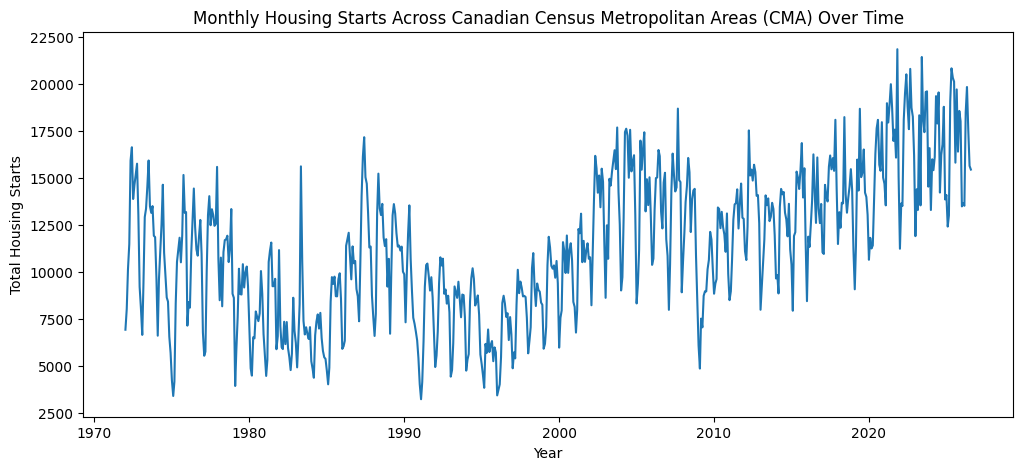

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(monthly_total["REF_DATE"], monthly_total["VALUE"])
plt.xlabel("Year")
plt.ylabel("Total Housing Starts")
plt.title("Monthly Housing Starts Across Canadian Census Metropolitan Areas (CMA) Over Time")
plt.show()

In [ ]:
clean_df["REF_DATE"] = pd.to_datetime(clean_df["REF_DATE"])

clean_df["Month"] = clean_df["REF_DATE"].dt.month_name()

seasonality = (
    clean_df.groupby("Month")["VALUE"]
    .mean()
    .reindex([
        "January", "February", "March", "April", "May", "June",
        "July", "August", "September", "October", "November", "December"
    ])
)

seasonality

,VALUE
Month,
January,266.179873
February,257.624060
March,293.766917
April,381.628687
May,417.211105
June,428.720648
July,402.828224
August,384.134182
September,389.296580


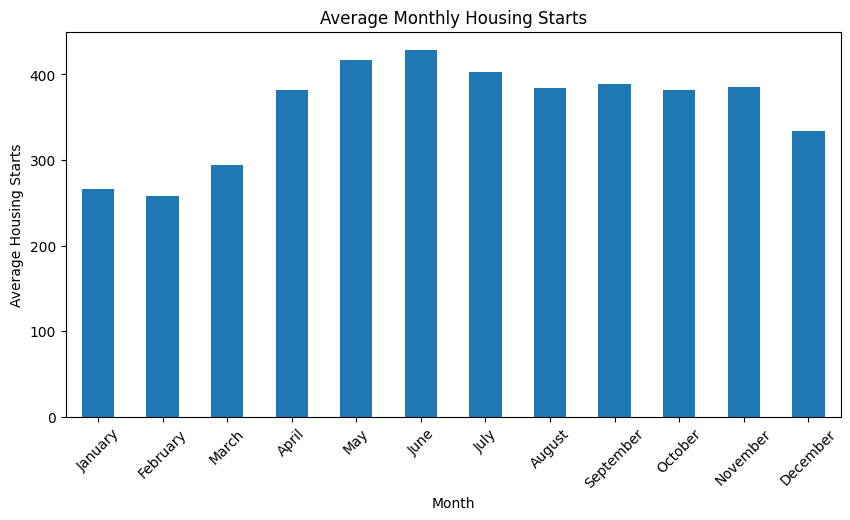

In [ ]:
plt.figure(figsize=(10, 5))

seasonality.plot(kind="bar")

plt.xlabel("Month")
plt.ylabel("Average Housing Starts")
plt.title("Average Monthly Housing Starts")
plt.xticks(rotation=45)
plt.show()

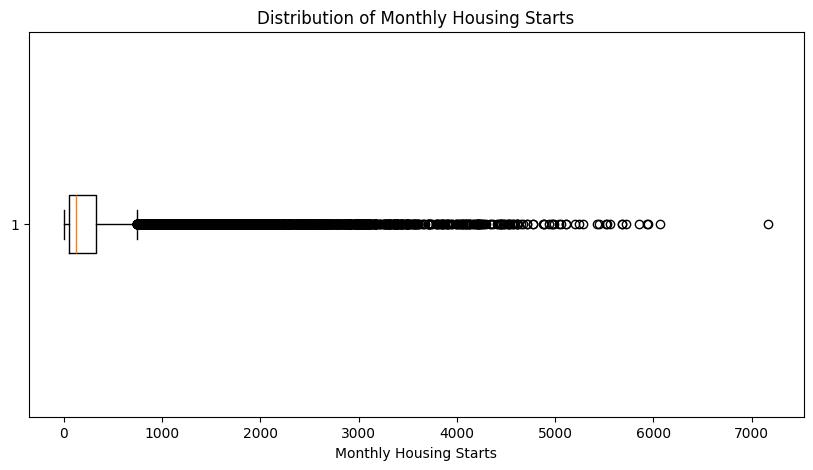

In [ ]:
plt.figure(figsize=(10, 5))

plt.boxplot(clean_df["VALUE"], vert=False)

plt.xlabel("Monthly Housing Starts")
plt.title("Distribution of Monthly Housing Starts")
plt.show()

In [ ]:
clean_df["VALUE"].quantile([0.25, 0.5, 0.75, 0.95, 0.99])

,VALUE
0.25,51.00
0.50,127.00
0.75,327.00
0.95,1657.50
0.99,3277.35


In [ ]:
clean_df.nlargest(10, "VALUE")[["REF_DATE", "GEO", "VALUE"]]

,REF_DATE,GEO,VALUE
17417,2023-06-01,"Toronto, Ontario",7171
17181,2003-10-01,"Toronto, Ontario",6070
17202,2005-07-01,"Toronto, Ontario",5947
17398,2021-11-01,"Toronto, Ontario",5940
17411,2022-12-01,"Toronto, Ontario",5852
16996,1988-05-01,"Toronto, Ontario",5724
17283,2012-04-01,"Toronto, Ontario",5679
17353,2018-02-01,"Toronto, Ontario",5677
17191,2004-08-01,"Toronto, Ontario",5558
17323,2015-08-01,"Toronto, Ontario",5529


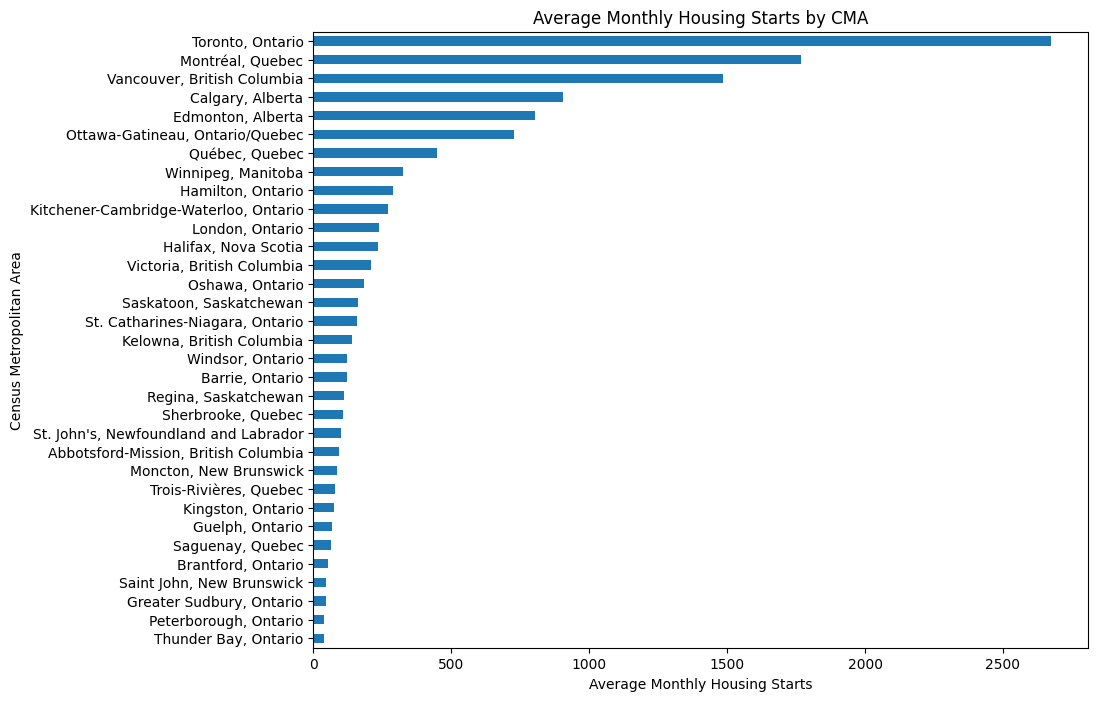

In [ ]:
cma_average = (
    clean_df.groupby("GEO")["VALUE"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 8))

cma_average.plot(kind="barh")

plt.xlabel("Average Monthly Housing Starts")
plt.ylabel("Census Metropolitan Area")
plt.title("Average Monthly Housing Starts by CMA")
plt.gca().invert_yaxis()
plt.show()

Dataset Pre-processing

In [ ]:
import pandas as pd
import numpy as np

clean_df = pd.read_csv("/content/drive/MyDrive/CSCI3052U - Group Project (Team 9)/cleaned_housing.csv")

clean_df.head()

,REF_DATE,GEO,Housing estimates,Type of unit,VALUE
0,1987-01-01,"Abbotsford-Mission, British Columbia",Housing starts,Total units,26
1,1987-02-01,"Abbotsford-Mission, British Columbia",Housing starts,Total units,70
2,1987-03-01,"Abbotsford-Mission, British Columbia",Housing starts,Total units,145
3,1987-04-01,"Abbotsford-Mission, British Columbia",Housing starts,Total units,224
4,1987-05-01,"Abbotsford-Mission, British Columbia",Housing starts,Total units,214


In [ ]:
clean_df["REF_DATE"] = pd.to_datetime(clean_df["REF_DATE"])

clean_df.dtypes

,0
REF_DATE,datetime64[ns]
GEO,object
Housing estimates,object
Type of unit,object
VALUE,int64


In [ ]:
clean_df = clean_df.sort_values(["GEO", "REF_DATE"]).reset_index(drop=True)

In [ ]:
# Lag Feature | Previous month housing starts

# Month of the year
clean_df["month"] = clean_df["REF_DATE"].dt.month

# What happened a month ago
clean_df["starts_lag_1"] = clean_df.groupby("GEO")["VALUE"].shift(1)

# What happened 2 months ago
clean_df["starts_lag_2"] = clean_df.groupby("GEO")["VALUE"].shift(2)

# What happend 3 months ago
clean_df["starts_lag_3"] = clean_df.groupby("GEO")["VALUE"].shift(3)

# What happened 12 months ago / year
clean_df["starts_lag_12"] = (
    clean_df.groupby("GEO")["VALUE"].shift(12)
)

clean_df[
    ["REF_DATE", "GEO", "VALUE","month",
     "starts_lag_1", "starts_lag_2", "starts_lag_3", "starts_lag_12"]
].head(13)

,REF_DATE,GEO,VALUE,month,starts_lag_1,starts_lag_2,starts_lag_3,starts_lag_12
0,1987-01-01,"Abbotsford-Mission, British Columbia",26,1,NaN,NaN,NaN,NaN
1,1987-02-01,"Abbotsford-Mission, British Columbia",70,2,26.0,NaN,NaN,NaN
2,1987-03-01,"Abbotsford-Mission, British Columbia",145,3,70.0,26.0,NaN,NaN
3,1987-04-01,"Abbotsford-Mission, British Columbia",224,4,145.0,70.0,26.0,NaN
4,1987-05-01,"Abbotsford-Mission, British Columbia",214,5,224.0,145.0,70.0,NaN
5,1987-06-01,"Abbotsford-Mission, British Columbia",133,6,214.0,224.0,145.0,NaN
6,1987-07-01,"Abbotsford-Mission, British Columbia",154,7,133.0,214.0,224.0,NaN
7,1987-08-01,"Abbotsford-Mission, British Columbia",121,8,154.0,133.0,214.0,NaN
8,1987-09-01,"Abbotsford-Mission, British Columbia",160,9,121.0,154.0,133.0,NaN
9,1987-10-01,"Abbotsford-Mission, British Columbia",284,10,160.0,121.0,154.0,NaN


In [ ]:
import numpy as np

# Rolling Averages | Month-to-month & Percentage change

# 3-month rolling average | Short-term trend
clean_df["starts_3m_avg"] = (
    clean_df.groupby("GEO")["VALUE"]
    .transform(lambda x: x.rolling(window=3).mean())
)

# 6-month rolling average | long-term trend
clean_df["starts_6m_avg"] = (
    clean_df.groupby("GEO")["VALUE"]
    .transform(lambda x: x.rolling(window=6).mean())
)

# Month-to-month change | Increase or decrease in units
clean_df["monthly_change"] = (
    clean_df["VALUE"] - clean_df["starts_lag_1"]
)

# Month-to-month percentage change
# Set to NaN when previous month's starts = 0

clean_df["starts_lag_1"] = clean_df.groupby("GEO")["VALUE"].shift(1)

clean_df["monthly_pct_change"] = np.where(
    clean_df["starts_lag_1"] == 0,
    np.nan,
    ((clean_df["VALUE"] - clean_df["starts_lag_1"])
     / clean_df["starts_lag_1"]) * 100
)

clean_df[
    [
        "REF_DATE",
        "GEO",
        "VALUE",
        "starts_lag_1",
        "starts_3m_avg",
        "starts_6m_avg",
        "monthly_change",
        "monthly_pct_change"
    ]
].head(10)

,REF_DATE,GEO,VALUE,starts_lag_1,starts_3m_avg,starts_6m_avg,monthly_change,monthly_pct_change
0,1987-01-01,"Abbotsford-Mission, British Columbia",26,NaN,NaN,NaN,NaN,NaN
1,1987-02-01,"Abbotsford-Mission, British Columbia",70,26.0,NaN,NaN,44.0,169.230769
2,1987-03-01,"Abbotsford-Mission, British Columbia",145,70.0,80.333333,NaN,75.0,107.142857
3,1987-04-01,"Abbotsford-Mission, British Columbia",224,145.0,146.333333,NaN,79.0,54.482759
4,1987-05-01,"Abbotsford-Mission, British Columbia",214,224.0,194.333333,NaN,-10.0,-4.464286
5,1987-06-01,"Abbotsford-Mission, British Columbia",133,214.0,190.333333,135.333333,-81.0,-37.850467
6,1987-07-01,"Abbotsford-Mission, British Columbia",154,133.0,167.000000,156.666667,21.0,15.789474
7,1987-08-01,"Abbotsford-Mission, British Columbia",121,154.0,136.000000,165.166667,-33.0,-21.428571
8,1987-09-01,"Abbotsford-Mission, British Columbia",160,121.0,145.000000,167.666667,39.0,32.231405
9,1987-10-01,"Abbotsford-Mission, British Columbia",284,160.0,188.333333,177.666667,124.0,77.500000


In [ ]:
# Classification and Regression Target

import numpy as np

# Regression target | Looking at the next month
clean_df["next_month_starts"] = (
    clean_df.groupby("GEO")["VALUE"].shift(-1)
)

# Classification target | 1 = Increase, 0 = Decrease or no increase
clean_df["direction"] = np.where(
    clean_df["next_month_starts"].isna(),
    np.nan,
    np.where(
        clean_df["next_month_starts"] > clean_df["VALUE"],
        1,
        0
    )
)

clean_df[
    [
        "REF_DATE",
        "GEO",
        "VALUE",
        "next_month_starts",
        "direction"
    ]
].head(10)

In [ ]:
clean_df[
    [
        "REF_DATE",
        "GEO",
        "VALUE",
        "month",
        "starts_lag_1",
        "starts_lag_2",
        "starts_lag_3",
        "starts_lag_12",
        "starts_3m_avg",
        "starts_6m_avg",
        "monthly_change",
        "monthly_pct_change",
        "next_month_starts",
        "direction"
    ]
].head(20)

,REF_DATE,GEO,VALUE,month,starts_lag_1,starts_lag_2,starts_lag_3,starts_lag_12,starts_3m_avg,starts_6m_avg,monthly_change,monthly_pct_change,next_month_starts,direction
0,1987-01-01,"Abbotsford-Mission, British Columbia",26,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.0,1.0
1,1987-02-01,"Abbotsford-Mission, British Columbia",70,2,26.0,NaN,NaN,NaN,NaN,NaN,44.0,169.230769,145.0,1.0
2,1987-03-01,"Abbotsford-Mission, British Columbia",145,3,70.0,26.0,NaN,NaN,80.333333,NaN,75.0,107.142857,224.0,1.0
3,1987-04-01,"Abbotsford-Mission, British Columbia",224,4,145.0,70.0,26.0,NaN,146.333333,NaN,79.0,54.482759,214.0,0.0
4,1987-05-01,"Abbotsford-Mission, British Columbia",214,5,224.0,145.0,70.0,NaN,194.333333,NaN,-10.0,-4.464286,133.0,0.0
5,1987-06-01,"Abbotsford-Mission, British Columbia",133,6,214.0,224.0,145.0,NaN,190.333333,135.333333,-81.0,-37.850467,154.0,1.0
6,1987-07-01,"Abbotsford-Mission, British Columbia",154,7,133.0,214.0,224.0,NaN,167.000000,156.666667,21.0,15.789474,121.0,0.0
7,1987-08-01,"Abbotsford-Mission, British Columbia",121,8,154.0,133.0,214.0,NaN,136.000000,165.166667,-33.0,-21.428571,160.0,1.0
8,1987-09-01,"Abbotsford-Mission, British Columbia",160,9,121.0,154.0,133.0,NaN,145.000000,167.666667,39.0,32.231405,284.0,1.0
9,1987-10-01,"Abbotsford-Mission, British Columbia",284,10,160.0,121.0,154.0,NaN,188.333333,177.666667,124.0,77.500000,86.0,0.0
